In [1]:
# ============================================================
# NOTEBOOK 11 — AGENTE EJECUTIVO DE RIESGO
# ============================================================
# Propósito  : Orquestador que integra el Agente de Originación
#              y el Agente de Cobranza para generar reportes
#              ejecutivos de riesgo crediticio.
#
# Tecnología : LangGraph — grafos de estados para agentes
#              con flujos de decisión complejos.
#
# Diferencia con agentes anteriores:
#   Originación y Cobranza tienen flujos LINEALES:
#   datos → modelo → LLM → respuesta
#
#   El Agente Ejecutivo tiene flujo con DECISIONES:
#   pregunta → clasificar → ¿qué agente consultar?
#            → consultar agente(s) → integrar → reporte
#
# Autor      : Marín Serrato Barrios
# Fecha      : Mayo 2026
# ============================================================

# ── Librerías generales ──────────────────────────────────────
import os
import sys
import json
import joblib
import warnings
import numpy as np
import pandas as pd
from pathlib import Path
from datetime import datetime
warnings.filterwarnings('ignore')

# ── LangGraph — orquestación de agentes ─────────────────────
# StateGraph : clase principal para construir el grafo
# END        : nodo terminal del grafo
from langgraph.graph import StateGraph, END

# TypedDict  : define la estructura del estado del agente
# Annotated  : permite agregar metadata a los tipos
from typing import TypedDict, Annotated, List, Optional
import operator

# ── LangChain — integración con Claude API ───────────────────
# ChatAnthropic : wrapper de LangChain para Claude API
from langchain_anthropic import ChatAnthropic
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage

# ── Herramientas del proyecto ────────────────────────────────
import anthropic   # Claude API directo (para los sub-agentes)
import shap

# ── Rutas del proyecto ───────────────────────────────────────
BASE        = Path(os.path.abspath('..')).resolve()
MODELS_PATH = BASE / 'dashboard' / 'models'
DATA_PATH   = BASE / 'data' / 'processed'
COLL_PATH   = BASE / 'src' / 'collections'

# Fix SSL para entorno conda en Windows
os.environ.pop('SSL_CERT_FILE', None)
os.environ.pop('SSL_CERT_DIR', None)

# ── Configurar API key ───────────────────────────────────────
def obtener_api_key():
    """Lee la API key desde .env o secrets.toml"""
    # Variable de entorno
    api_key = os.environ.get('ANTHROPIC_API_KEY')
    if api_key:
        return api_key

    # .env en raíz
    env_path = BASE / '.env'
    if env_path.exists():
        with open(env_path, 'r') as f:
            for linea in f:
                if linea.startswith('ANTHROPIC_API_KEY'):
                    return linea.split('=')[1].strip() \
                                .strip('"').strip("'")

    # Streamlit secrets
    secrets_path = BASE / 'dashboard' / '.streamlit' / 'secrets.toml'
    if secrets_path.exists():
        with open(secrets_path, 'r') as f:
            for linea in f:
                if 'ANTHROPIC_API_KEY' in linea:
                    return linea.split('=')[1].strip() \
                                .strip('"').strip("'")
    return None

API_KEY = obtener_api_key()

if API_KEY:
    os.environ['ANTHROPIC_API_KEY'] = API_KEY
    print("✅ API key configurada")
else:
    print("❌ API key no encontrada")

print('✅ Librerías cargadas')
print(f'   LangGraph  : importado')
print(f'   Base       : {BASE}')
print(f'   Modelos    : {MODELS_PATH}')

✅ API key configurada
✅ Librerías cargadas
   LangGraph  : importado
   Base       : C:\Users\Marin\Documents\PROYECTO ML_OPS\credit-risk-scoring-ml
   Modelos    : C:\Users\Marin\Documents\PROYECTO ML_OPS\credit-risk-scoring-ml\dashboard\models


In [2]:
# ============================================================
# CELDA 2 — ESTADO DEL AGENTE EJECUTIVO
# ============================================================
# El estado es el "portafolio de información" que fluye
# entre los nodos del grafo.
#
# Cada nodo:
# 1. Recibe el estado actual
# 2. Hace su trabajo
# 3. Devuelve campos actualizados del estado
#
# Annotated[List, operator.add] significa que cuando
# múltiples nodos agregan a esa lista, se concatenan
# en lugar de sobreescribirse.
# ============================================================

class EstadoAgenteEjecutivo(TypedDict):
    """
    Estado completo del Agente Ejecutivo de Riesgo.
    Todos los campos son opcionales excepto 'pregunta'.
    """

    # ── Input del analista ───────────────────────────────────
    # La pregunta que hace el analista al agente
    pregunta: str

    # ── Clasificación de la pregunta ─────────────────────────
    # Qué tipo de pregunta es: 'originacion', 'cobranza',
    # 'ambos', 'general'
    tipo_consulta: Optional[str]

    # ── Resultados de cada sub-agente ────────────────────────
    # Datos y análisis del Agente de Originación
    resultado_originacion: Optional[dict]

    # Datos y análisis del Agente de Cobranza
    resultado_cobranza: Optional[dict]

    # ── Reporte final ────────────────────────────────────────
    # El reporte ejecutivo integrado generado por Claude
    reporte_ejecutivo: Optional[str]

    # ── Historial de mensajes ────────────────────────────────
    # Annotated con operator.add permite que múltiples nodos
    # agreguen mensajes sin sobreescribirse
    mensajes: Annotated[List, operator.add]

    # ── Metadata de la ejecución ─────────────────────────────
    # Registro de qué nodos se ejecutaron y cuándo
    pasos_ejecutados: Annotated[List, operator.add]


# ── Verificar la estructura del estado ───────────────────────
print("✅ Estado del Agente Ejecutivo definido:")
print(f"   Campos del estado:")
for campo, tipo in EstadoAgenteEjecutivo.__annotations__.items():
    print(f"   • {campo:<30} : {tipo}")

✅ Estado del Agente Ejecutivo definido:
   Campos del estado:
   • pregunta                       : <class 'str'>
   • tipo_consulta                  : typing.Optional[str]
   • resultado_originacion          : typing.Optional[dict]
   • resultado_cobranza             : typing.Optional[dict]
   • reporte_ejecutivo              : typing.Optional[str]
   • mensajes                       : typing.Annotated[typing.List, <built-in function add>]
   • pasos_ejecutados               : typing.Annotated[typing.List, <built-in function add>]


In [3]:
# ============================================================
# CELDA 3 — CARGAR MODELOS DE LOS SUB-AGENTES
# ============================================================
# El Agente Ejecutivo no entrena modelos nuevos.
# Carga los artefactos ya construidos en las fases anteriores
# y los usa como herramientas para responder preguntas.
# ============================================================

print("=" * 55)
print("CARGANDO ARTEFACTOS DE LOS SUB-AGENTES")
print("=" * 55)

# ── Agente de Originación ────────────────────────────────────
print("\n[1/4] Agente de Originación...")

modelo_orig = joblib.load(MODELS_PATH / 'model.pkl')
print(f"      ✅ LightGBM originación cargado")

# Cargar datos procesados para métricas del portfolio
try:
    df_app = pd.read_csv(
        DATA_PATH / 'df_collections.csv',
        usecols=['SK_ID_CURR', 'TARGET', 'AMT_CREDIT',
                 'AMT_ANNUITY', 'AMT_INCOME_TOTAL',
                 'NAME_CONTRACT_TYPE']
    )
    print(f"      ✅ Dataset portfolio: {df_app.shape[0]:,} clientes")
except:
    df_app = None
    print(f"      ⚠️  Dataset portfolio no disponible")

# ── Agente de Cobranza ───────────────────────────────────────
print("\n[2/4] Agente de Cobranza (EWS)...")

modelo_ews      = joblib.load(MODELS_PATH / 'modelo_ews.pkl')
metadata_ews    = joblib.load(MODELS_PATH / 'ews_metadata.pkl')
shap_ews        = joblib.load(MODELS_PATH / 'shap_ews_explainer.pkl')
chroma_config   = joblib.load(MODELS_PATH / 'chroma_config.pkl')

print(f"      ✅ LightGBM EWS cargado")
print(f"         AUC   : {metadata_ews['metricas']['auc_roc']}")
print(f"         KS    : {metadata_ews['metricas']['ks']}")
print(f"         Recall: {metadata_ews['metricas']['recall']:.1%}")

# ── ChromaDB para RAG ────────────────────────────────────────
print("\n[3/4] ChromaDB (base de conocimiento RAG)...")

import chromadb
from sentence_transformers import SentenceTransformer

chroma_client = chromadb.PersistentClient(
    path=chroma_config['chroma_path']
)
coleccion_rag = chroma_client.get_collection(
    chroma_config['collection_name']
)
modelo_emb = SentenceTransformer(
    chroma_config['modelo_embeddings']
)

print(f"      ✅ ChromaDB cargado")
print(f"         Chunks indexados: {coleccion_rag.count()}")

# ── Cargar dataset EWS para métricas de cobranza ─────────────
print("\n[4/4] Dataset EWS para métricas de cobranza...")

try:
    df_ews = pd.read_csv(
        DATA_PATH / 'df_ews.csv',
        usecols=['SK_ID_CURR', 'TARGET_EWS',
                 'max_dias_atraso', 'AMT_CREDIT',
                 'carga_financiera', 'es_cliente_recurrente']
    )
    print(f"      ✅ Dataset EWS: {df_ews.shape[0]:,} clientes")
except:
    df_ews = None
    print(f"      ⚠️  Dataset EWS no disponible")

print(f"\n{'='*55}")
print("RESUMEN DE ARTEFACTOS CARGADOS")
print(f"{'='*55}")
print(f"  Agente Originación : LightGBM model.pkl ✅")
print(f"  Agente Cobranza    : EWS + SHAP + RAG   ✅")
print(f"  ChromaDB           : {coleccion_rag.count()} chunks ✅")
print(f"  API key            : {'✅ configurada' if API_KEY else '❌ falta'}")

CARGANDO ARTEFACTOS DE LOS SUB-AGENTES

[1/4] Agente de Originación...
      ✅ LightGBM originación cargado
      ✅ Dataset portfolio: 307,511 clientes

[2/4] Agente de Cobranza (EWS)...
      ✅ LightGBM EWS cargado
         AUC   : 0.8712
         KS    : 0.5719
         Recall: 79.6%

[3/4] ChromaDB (base de conocimiento RAG)...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

      ✅ ChromaDB cargado
         Chunks indexados: 17

[4/4] Dataset EWS para métricas de cobranza...
      ✅ Dataset EWS: 234,620 clientes

RESUMEN DE ARTEFACTOS CARGADOS
  Agente Originación : LightGBM model.pkl ✅
  Agente Cobranza    : EWS + SHAP + RAG   ✅
  ChromaDB           : 17 chunks ✅
  API key            : ✅ configurada


In [4]:
# ============================================================
# CELDA 4 — FUNCIONES DE LOS SUB-AGENTES
# ============================================================
# Cada sub-agente expone una función que el Agente Ejecutivo
# puede llamar. Las funciones devuelven datos estructurados
# (diccionarios) que el agente puede usar para generar
# el reporte ejecutivo.
# ============================================================

def consultar_agente_originacion() -> dict:
    """
    Extrae métricas clave del Agente de Originación.
    Devuelve un resumen del estado actual de la originación.

    En producción real estos datos vendrían de la base de datos
    de solicitudes del día/semana actual.
    Para el portfolio usamos el dataset histórico.
    """
    if df_app is None:
        return {'error': 'Dataset de originación no disponible'}

    # Métricas del portfolio
    n_total        = len(df_app)
    n_mora         = df_app['TARGET'].sum()
    tasa_mora      = df_app['TARGET'].mean()
    monto_promedio = df_app['AMT_CREDIT'].mean()
    monto_total    = df_app['AMT_CREDIT'].sum()
    carga_fin_prom = (
        df_app['AMT_ANNUITY'] /
        (df_app['AMT_INCOME_TOTAL'] / 12)
    ).mean()

    # Mix de productos
    mix_productos = df_app['NAME_CONTRACT_TYPE'] \
                    .value_counts(normalize=True) \
                    .to_dict()

    # Segmentación por riesgo simulada con el modelo
    # (en producción vendría de las predicciones reales)
    np.random.seed(42)
    pds_simuladas = np.random.beta(
        2, 10, size=min(1000, n_total)
    )
    bajo_riesgo   = (pds_simuladas < 0.15).mean()
    medio_riesgo  = ((pds_simuladas >= 0.15) &
                     (pds_simuladas < 0.35)).mean()
    alto_riesgo   = (pds_simuladas >= 0.35).mean()

    return {
        'fuente'           : 'Agente de Originación',
        'periodo'          : 'Histórico dataset Home Credit',
        'n_solicitudes'    : n_total,
        'n_en_mora'        : int(n_mora),
        'tasa_mora'        : round(tasa_mora, 4),
        'monto_promedio'   : round(monto_promedio, 0),
        'cartera_total'    : round(monto_total, 0),
        'carga_fin_prom'   : round(carga_fin_prom, 4),
        'mix_productos'    : {
            k: round(v, 3)
            for k, v in mix_productos.items()
        },
        'segmentacion_riesgo': {
            'bajo_riesgo'  : round(bajo_riesgo, 3),
            'medio_riesgo' : round(medio_riesgo, 3),
            'alto_riesgo'  : round(alto_riesgo, 3),
        },
        'modelo'           : {
            'nombre' : 'LightGBM',
            'auc'    : 0.768,
            'ks'     : 0.47,
        }
    }


def consultar_agente_cobranza() -> dict:
    """
    Extrae métricas clave del Agente de Cobranza (EWS).
    Devuelve el estado actual de la cartera en riesgo.
    """
    if df_ews is None:
        return {'error': 'Dataset EWS no disponible'}

    # Métricas del EWS
    n_total        = len(df_ews)
    n_alerta       = (df_ews['TARGET_EWS'] == 1).sum()
    tasa_alerta    = df_ews['TARGET_EWS'].mean()

    # Clientes por nivel de mora
    def nivel_mora(dias):
        if dias == 0:      return 'preventiva'
        elif dias <= 7:    return 'alerta_temprana'
        elif dias <= 30:   return 'mora_leve'
        elif dias <= 90:   return 'mora_media'
        else:              return 'mora_grave'

    df_ews['nivel'] = df_ews['max_dias_atraso'].apply(nivel_mora)
    dist_mora = df_ews['nivel'].value_counts().to_dict()

    # Cartera en riesgo
    cartera_en_riesgo = df_ews[
        df_ews['TARGET_EWS'] == 1
    ]['AMT_CREDIT'].sum() if 'AMT_CREDIT' in df_ews.columns \
    else None

    # Perfil de clientes en alerta
    df_alerta = df_ews[df_ews['TARGET_EWS'] == 1]
    pct_recurrentes = df_alerta[
        'es_cliente_recurrente'
    ].mean() if len(df_alerta) > 0 else 0

    carga_prom_alerta = df_alerta[
        'carga_financiera'
    ].mean() if len(df_alerta) > 0 else 0

    return {
        'fuente'              : 'Agente de Cobranza (EWS)',
        'periodo'             : 'Dataset Home Credit',
        'n_clientes_activos'  : n_total,
        'n_en_alerta_ews'     : int(n_alerta),
        'tasa_alerta'         : round(tasa_alerta, 4),
        'distribucion_mora'   : dist_mora,
        'pct_recurrentes_alerta': round(pct_recurrentes, 3),
        'carga_fin_alerta'    : round(carga_prom_alerta, 3),
        'umbral_decision'     : 0.20,
        'modelo'              : {
            'nombre' : 'LightGBM EWS',
            'auc'    : metadata_ews['metricas']['auc_roc'],
            'ks'     : metadata_ews['metricas']['ks'],
            'recall' : metadata_ews['metricas']['recall'],
        },
        'analisis_costo'      : {
            'c_gestion_mxn'   : 100,
            'c_mora_mxn'      : 89_854,
            'ahorro_vs_050'   : 281_107_044,
        }
    }


# ── Probar las funciones ─────────────────────────────────────
print("=" * 55)
print("PRUEBA DE FUNCIONES DE SUB-AGENTES")
print("=" * 55)

print("\n[Agente Originación]")
res_orig = consultar_agente_originacion()
for k, v in res_orig.items():
    if not isinstance(v, dict):
        print(f"  {k:<30}: {v}")

print("\n[Agente Cobranza]")
res_cob = consultar_agente_cobranza()
for k, v in res_cob.items():
    if not isinstance(v, dict):
        print(f"  {k:<30}: {v}")

print("\n✅ Funciones de sub-agentes listas")

PRUEBA DE FUNCIONES DE SUB-AGENTES

[Agente Originación]
  fuente                        : Agente de Originación
  periodo                       : Histórico dataset Home Credit
  n_solicitudes                 : 307511
  n_en_mora                     : 24825
  tasa_mora                     : 0.0807
  monto_promedio                : 599026.0
  cartera_total                 : 184207084196.0
  carga_fin_prom                : 2.1712

[Agente Cobranza]
  fuente                        : Agente de Cobranza (EWS)
  periodo                       : Dataset Home Credit
  n_clientes_activos            : 234620
  n_en_alerta_ews               : 51535
  tasa_alerta                   : 0.2197
  pct_recurrentes_alerta        : 1.0
  carga_fin_alerta              : 2.161
  umbral_decision               : 0.2

✅ Funciones de sub-agentes listas


In [8]:
# ============================================================
# CELDA 5 — NODOS DEL GRAFO LANGGRAPH
# ============================================================
# Cada nodo es una función que:
# 1. Recibe el estado actual (EstadoAgenteEjecutivo)
# 2. Hace su trabajo
# 3. Devuelve un dict con los campos a actualizar
#
# IMPORTANTE: los nodos NO devuelven el estado completo,
# solo los campos que modifican. LangGraph hace el merge
# automáticamente.
#
# Nodos del grafo:
# ┌──────────────────────────────────────────────────────┐
# │ clasificar_pregunta → decide qué agente(s) consultar │
# │ nodo_originacion    → consulta métricas de orig.     │
# │ nodo_cobranza       → consulta métricas de cob.      │
# │ nodo_ambos          → consulta ambos agentes         │
# │ generar_reporte     → integra y genera reporte       │
# └──────────────────────────────────────────────────────┘
# ============================================================

# ── Nodo 1: Clasificar la pregunta (Opción B — Claude) ───────
def clasificar_pregunta(estado: EstadoAgenteEjecutivo) -> dict:
    """
    Usa Claude API para clasificar la intención de la pregunta.
    Más robusto que keywords hardcodeadas — entiende contexto
    y sinónimos sin depender de palabras exactas.

    Clasificaciones posibles:
    - 'originacion' : pregunta sobre solicitudes, aprobaciones,
                      score, PD, nuevos créditos, colocación
    - 'cobranza'    : pregunta sobre mora, atrasos, EWS,
                      clientes en riesgo, recuperación
    - 'ambos'       : reporte general, cartera completa,
                      situación global de riesgo
    """
    pregunta = estado['pregunta']

    # Prompt de clasificación — tarea simple para Claude
    # Usamos max_tokens=5 porque solo necesitamos una palabra
    prompt_clasificacion = f"""Eres un clasificador de intenciones para un sistema
de riesgo crediticio. Clasifica la siguiente pregunta en UNA sola palabra.

Opciones válidas (solo estas tres):
- originacion : preguntas sobre solicitudes nuevas, aprobaciones, score crediticio,
                probabilidad de incumplimiento, colocación, nuevos créditos
- cobranza    : preguntas sobre mora, atrasos, clientes en riesgo, EWS,
                early warning, recuperación, gestión de cartera vencida
- ambos       : preguntas sobre el estado general de la cartera, reportes
                ejecutivos, situación global de riesgo, resúmenes

Pregunta: {pregunta}

Responde ÚNICAMENTE con una de estas tres palabras: originacion, cobranza, ambos
No agregues puntuación, explicación ni ninguna otra palabra."""

    try:
        cliente = anthropic.Anthropic(api_key=API_KEY)
        respuesta = cliente.messages.create(
            model      = "claude-sonnet-4-20250514",
            max_tokens = 10,   # Solo necesitamos una palabra
            messages   = [{
                "role"   : "user",
                "content": prompt_clasificacion
            }]
        )

        # Limpiar y validar la respuesta
        tipo = respuesta.content[0].text.strip().lower()

        # Validar que sea una de las opciones válidas
        opciones_validas = {'originacion', 'cobranza', 'ambos'}
        if tipo not in opciones_validas:
            # Si Claude devolvió algo inesperado, usar 'ambos'
            print(f"   ⚠️  Clasificación inesperada: '{tipo}' → usando 'ambos'")
            tipo = 'ambos'

    except Exception as e:
        # Si falla la API, usar 'ambos' como fallback seguro
        print(f"   ⚠️  Error en clasificación: {e} → usando 'ambos'")
        tipo = 'ambos'

    print(f"   📋 Pregunta clasificada como: '{tipo}'")

    return {
        'tipo_consulta'   : tipo,
        'pasos_ejecutados': [
            f"[{datetime.now().strftime('%H:%M:%S')}] "
            f"Pregunta clasificada por Claude → {tipo}"
        ]
    }


# ── Nodo 2: Consultar Agente de Originación ──────────────────
def nodo_originacion(estado: EstadoAgenteEjecutivo) -> dict:
    """
    Consulta el Agente de Originación y obtiene métricas
    del estado actual de la originación de créditos.
    """
    print(f"   🏦 Consultando Agente de Originación...")

    resultado = consultar_agente_originacion()

    return {
        'resultado_originacion': resultado,
        'pasos_ejecutados'     : [
            f"[{datetime.now().strftime('%H:%M:%S')}] "
            f"Agente Originación consultado — "
            f"{resultado.get('n_solicitudes', 0):,} solicitudes"
        ]
    }


# ── Nodo 3: Consultar Agente de Cobranza ─────────────────────
def nodo_cobranza(estado: EstadoAgenteEjecutivo) -> dict:
    """
    Consulta el Agente de Cobranza y obtiene métricas
    del EWS y el estado de la cartera en mora.
    """
    print(f"   🚨 Consultando Agente de Cobranza (EWS)...")

    resultado = consultar_agente_cobranza()

    return {
        'resultado_cobranza': resultado,
        'pasos_ejecutados'  : [
            f"[{datetime.now().strftime('%H:%M:%S')}] "
            f"Agente Cobranza consultado — "
            f"{resultado.get('n_en_alerta_ews', 0):,} alertas EWS"
        ]
    }


# ── Nodo 4: Consultar ambos agentes ──────────────────────────
def nodo_ambos(estado: EstadoAgenteEjecutivo) -> dict:
    """
    Consulta ambos agentes en secuencia.
    Se usa cuando la pregunta requiere una visión completa
    del riesgo crediticio.
    """
    print(f"   🔄 Consultando ambos agentes...")

    resultado_orig = consultar_agente_originacion()
    resultado_cob  = consultar_agente_cobranza()

    return {
        'resultado_originacion': resultado_orig,
        'resultado_cobranza'   : resultado_cob,
        'pasos_ejecutados'     : [
            f"[{datetime.now().strftime('%H:%M:%S')}] "
            f"Ambos agentes consultados"
        ]
    }


# ── Nodo 5: Generar reporte ejecutivo ────────────────────────
def generar_reporte(estado: EstadoAgenteEjecutivo) -> dict:
    """
    Nodo final — integra los resultados de los sub-agentes
    y genera el reporte ejecutivo con Claude API.

    Este nodo siempre se ejecuta al final, independientemente
    de qué sub-agentes fueron consultados.
    """
    print(f"   📊 Generando reporte ejecutivo con Claude API...")

    # Construir contexto con los datos disponibles
    contexto_partes = []

    if estado.get('resultado_originacion'):
        orig = estado['resultado_originacion']
        contexto_partes.append(f"""
DATOS DE ORIGINACIÓN:
  Solicitudes totales    : {orig.get('n_solicitudes', 'N/D'):,}
  Clientes en mora       : {orig.get('n_en_mora', 'N/D'):,}
  Tasa de mora           : {orig.get('tasa_mora', 0):.1%}
  Monto promedio crédito : ${orig.get('monto_promedio', 0):,.0f} MXN
  Cartera total          : ${orig.get('cartera_total', 0):,.0f} MXN
  Carga financiera prom. : {orig.get('carga_fin_prom', 0):.1%}
  AUC modelo             : {orig.get('modelo', {}).get('auc', 'N/D')}
        """.strip())

    if estado.get('resultado_cobranza'):
        cob = estado['resultado_cobranza']
        contexto_partes.append(f"""
DATOS DE COBRANZA (EWS):
  Clientes activos       : {cob.get('n_clientes_activos', 'N/D'):,}
  Alertas EWS activas    : {cob.get('n_en_alerta_ews', 'N/D'):,}
  Tasa de alerta         : {cob.get('tasa_alerta', 0):.1%}
  % recurrentes en alerta: {cob.get('pct_recurrentes_alerta', 0):.1%}
  Carga fin. en alerta   : {cob.get('carga_fin_alerta', 0):.1%}
  AUC modelo EWS         : {cob.get('modelo', {}).get('auc', 'N/D')}
  Recall EWS             : {cob.get('modelo', {}).get('recall', 0):.1%}
        """.strip())

    contexto = "\n\n".join(contexto_partes)

    # Prompt para el reporte ejecutivo
    prompt_sistema = """Eres el Agente Ejecutivo de Riesgo Crediticio.
Generas reportes ejecutivos concisos y accionables para la Dirección General
de una institución financiera mexicana.

INSTRUCCIONES:
- Usa los datos proporcionados — no inventes cifras
- Sé directo y ejecutivo — máximo 300 palabras
- Incluye siempre: situación actual, alertas y recomendaciones
- Usa lenguaje de negocios, no técnico
- Cumple con terminología regulatoria CNBV cuando aplique"""

    prompt_usuario = f"""
PREGUNTA DEL ANALISTA: {estado['pregunta']}

DATOS DISPONIBLES:
{'='*50}
{contexto}
{'='*50}

Genera el reporte ejecutivo respondiendo la pregunta.
Estructura:
1. SITUACIÓN ACTUAL (2-3 líneas con los números clave)
2. ALERTAS (qué requiere atención inmediata)
3. RECOMENDACIONES (máximo 3 acciones concretas)
"""

    try:
        cliente = anthropic.Anthropic(api_key=API_KEY)
        respuesta = cliente.messages.create(
            model      = "claude-sonnet-4-20250514",
            max_tokens = 600,
            system     = prompt_sistema,
            messages   = [{"role": "user", "content": prompt_usuario}]
        )
        reporte = respuesta.content[0].text

    except Exception as e:
        reporte = f"Error al generar reporte: {e}"

    return {
        'reporte_ejecutivo': reporte,
        'mensajes'         : [AIMessage(content=reporte)],
        'pasos_ejecutados' : [
            f"[{datetime.now().strftime('%H:%M:%S')}] "
            f"Reporte ejecutivo generado"
        ]
    }


# ── Función de enrutamiento ───────────────────────────────────
def enrutar_consulta(estado: EstadoAgenteEjecutivo) -> str:
    """
    Función de enrutamiento condicional.
    LangGraph la usa para decidir qué nodo ejecutar
    después de clasificar la pregunta.

    Retorna el nombre del nodo siguiente.
    """
    tipo = estado.get('tipo_consulta', 'ambos')

    if tipo == 'originacion':
        return 'nodo_originacion'
    elif tipo == 'cobranza':
        return 'nodo_cobranza'
    else:
        return 'nodo_ambos'


print("✅ Nodos del grafo definidos:")
print("   • clasificar_pregunta  → determina qué agente consultar")
print("   • nodo_originacion     → métricas de originación")
print("   • nodo_cobranza        → métricas EWS + cobranza")
print("   • nodo_ambos           → ambos agentes en secuencia")
print("   • generar_reporte      → reporte ejecutivo con Claude")
print("   • enrutar_consulta     → función de enrutamiento")

✅ Nodos del grafo definidos:
   • clasificar_pregunta  → determina qué agente consultar
   • nodo_originacion     → métricas de originación
   • nodo_cobranza        → métricas EWS + cobranza
   • nodo_ambos           → ambos agentes en secuencia
   • generar_reporte      → reporte ejecutivo con Claude
   • enrutar_consulta     → función de enrutamiento


✅ Grafo compilado exitosamente

Estructura del grafo:
  START
    └─► clasificar_pregunta
          ├─(originacion)─► nodo_originacion ─┐
          ├─(cobranza)────► nodo_cobranza    ─┤
          └─(ambos)───────► nodo_ambos       ─┘
                                               │
                                    generar_reporte
                                               │
                                             END


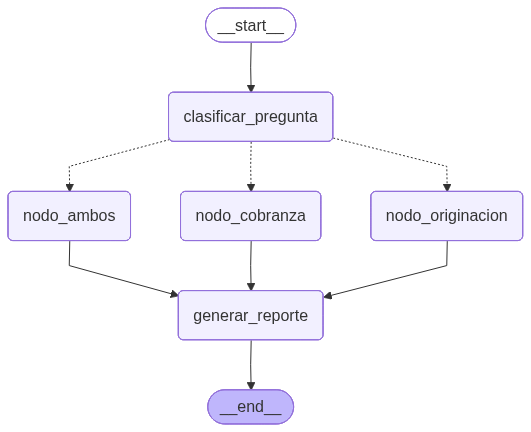


✅ Diagrama del grafo generado


In [9]:
# ============================================================
# CELDA 6 — CONSTRUIR Y COMPILAR EL GRAFO
# ============================================================
# Aquí ensamblamos el grafo conectando los nodos.
#
# El grafo tiene esta estructura:
#
# [START]
#    │
#    ▼
# [clasificar_pregunta]
#    │
#    ├──(originacion)──► [nodo_originacion] ──┐
#    ├──(cobranza)─────► [nodo_cobranza]    ──┤
#    └──(ambos)────────► [nodo_ambos]       ──┘
#                                             │
#                                             ▼
#                                    [generar_reporte]
#                                             │
#                                             ▼
#                                          [END]
# ============================================================

from langgraph.graph import START

# ── Crear el grafo con el tipo de estado ─────────────────────
grafo = StateGraph(EstadoAgenteEjecutivo)

# ── Agregar nodos ────────────────────────────────────────────
# Cada nodo tiene un nombre y la función que ejecuta
grafo.add_node("clasificar_pregunta", clasificar_pregunta)
grafo.add_node("nodo_originacion",    nodo_originacion)
grafo.add_node("nodo_cobranza",       nodo_cobranza)
grafo.add_node("nodo_ambos",          nodo_ambos)
grafo.add_node("generar_reporte",     generar_reporte)

# ── Definir el punto de entrada ──────────────────────────────
# El grafo siempre empieza en clasificar_pregunta
grafo.add_edge(START, "clasificar_pregunta")

# ── Arista condicional ───────────────────────────────────────
# Después de clasificar, la función enrutar_consulta decide
# qué nodo ejecutar según el tipo de pregunta
grafo.add_conditional_edges(
    "clasificar_pregunta",   # nodo origen
    enrutar_consulta,        # función de decisión
    {                        # mapa de posibles destinos
        "nodo_originacion": "nodo_originacion",
        "nodo_cobranza"   : "nodo_cobranza",
        "nodo_ambos"      : "nodo_ambos",
    }
)

# ── Aristas fijas hacia el reporte final ─────────────────────
# Independientemente del camino tomado, siempre termina
# en generar_reporte → END
grafo.add_edge("nodo_originacion", "generar_reporte")
grafo.add_edge("nodo_cobranza",    "generar_reporte")
grafo.add_edge("nodo_ambos",       "generar_reporte")
grafo.add_edge("generar_reporte",  END)

# ── Compilar el grafo ────────────────────────────────────────
# compile() valida la estructura y prepara el grafo
# para ejecución. Detecta errores de configuración.
agente_ejecutivo = grafo.compile()

print("✅ Grafo compilado exitosamente")
print()
print("Estructura del grafo:")
print("  START")
print("    └─► clasificar_pregunta")
print("          ├─(originacion)─► nodo_originacion ─┐")
print("          ├─(cobranza)────► nodo_cobranza    ─┤")
print("          └─(ambos)───────► nodo_ambos       ─┘")
print("                                               │")
print("                                    generar_reporte")
print("                                               │")
print("                                             END")

# ── Visualizar el grafo ──────────────────────────────────────
try:
    from IPython.display import Image, display
    img = agente_ejecutivo.get_graph().draw_mermaid_png()
    display(Image(img))
    print("\n✅ Diagrama del grafo generado")
except Exception as e:
    print(f"\n⚠️  Visualización no disponible: {e}")
    print("   El grafo funciona correctamente aunque")
    print("   no se pueda visualizar en este entorno.")

In [10]:
# ============================================================
# CELDA 7 — PRUEBAS DEL AGENTE EJECUTIVO
# ============================================================
# Objetivo: verificar que el grafo enruta correctamente
# según el tipo de pregunta y genera reportes coherentes.
#
# Probamos tres tipos de pregunta:
# 1. Solo originación → debe ir a nodo_originacion
# 2. Solo cobranza   → debe ir a nodo_cobranza
# 3. General         → debe ir a nodo_ambos
# ============================================================

def ejecutar_agente(pregunta: str,
                    verbose: bool = True) -> dict:
    """
    Ejecuta el Agente Ejecutivo con una pregunta.

    Parámetros:
    -----------
    pregunta : str — la pregunta del analista
    verbose  : bool — mostrar pasos de ejecución

    Retorna:
    --------
    dict — estado final del agente con el reporte
    """
    # Estado inicial — solo la pregunta es obligatoria
    estado_inicial = {
        'pregunta'        : pregunta,
        'tipo_consulta'   : None,
        'resultado_originacion': None,
        'resultado_cobranza'   : None,
        'reporte_ejecutivo'    : None,
        'mensajes'        : [HumanMessage(content=pregunta)],
        'pasos_ejecutados': [
            f"[{datetime.now().strftime('%H:%M:%S')}] "
            f"Pregunta recibida: {pregunta[:50]}..."
        ]
    }

    if verbose:
        print(f"\n{'='*60}")
        print(f"PREGUNTA: {pregunta}")
        print(f"{'='*60}")

    # Ejecutar el grafo
    resultado = agente_ejecutivo.invoke(estado_inicial)

    if verbose:
        print(f"\n{'─'*60}")
        print("REPORTE EJECUTIVO:")
        print(f"{'─'*60}")
        print(resultado['reporte_ejecutivo'])
        print(f"\n{'─'*60}")
        print(f"Pasos ejecutados:")
        for paso in resultado['pasos_ejecutados']:
            print(f"  {paso}")
        print(f"Nodo de consulta: {resultado['tipo_consulta']}")

    return resultado


# ── Prueba 1: Pregunta sobre originación ─────────────────────
print("\n" + "█"*60)
print("PRUEBA 1 — PREGUNTA SOBRE ORIGINACIÓN")
print("█"*60)

res1 = ejecutar_agente(
    "¿Cuál es la tasa de mora actual en la originación "
    "y cómo está el score promedio de los nuevos créditos?"
)

# ── Prueba 2: Pregunta sobre cobranza ────────────────────────
print("\n" + "█"*60)
print("PRUEBA 2 — PREGUNTA SOBRE COBRANZA")
print("█"*60)

res2 = ejecutar_agente(
    "¿Cuántos clientes están en alerta EWS esta semana "
    "y cuál es la estrategia de cobranza recomendada?"
)

# ── Prueba 3: Reporte general ────────────────────────────────
print("\n" + "█"*60)
print("PRUEBA 3 — REPORTE EJECUTIVO GENERAL")
print("█"*60)

res3 = ejecutar_agente(
    "Dame el reporte semanal de riesgo crediticio — "
    "necesito saber cómo está la cartera completa."
)

# ── Resumen de enrutamiento ──────────────────────────────────
print("\n" + "="*60)
print("RESUMEN DE ENRUTAMIENTO")
print("="*60)
print(f"  Prueba 1 (originación) → nodo: "
      f"{res1['tipo_consulta']}")
print(f"  Prueba 2 (cobranza)    → nodo: "
      f"{res2['tipo_consulta']}")
print(f"  Prueba 3 (general)     → nodo: "
      f"{res3['tipo_consulta']}")
print(f"\n✅ Agente Ejecutivo funcionando correctamente")


████████████████████████████████████████████████████████████
PRUEBA 1 — PREGUNTA SOBRE ORIGINACIÓN
████████████████████████████████████████████████████████████

PREGUNTA: ¿Cuál es la tasa de mora actual en la originación y cómo está el score promedio de los nuevos créditos?
   📋 Pregunta clasificada como: 'ambos'
   🔄 Consultando ambos agentes...
   📊 Generando reporte ejecutivo con Claude API...

────────────────────────────────────────────────────────────
REPORTE EJECUTIVO:
────────────────────────────────────────────────────────────
# REPORTE EJECUTIVO - RIESGO CREDITICIO

## SITUACIÓN ACTUAL
La cartera presenta una **tasa de mora del 8.1%** (24,825 clientes) sobre 307,511 solicitudes procesadas, con una exposición total de $184,207 millones. El monto promedio por crédito es de $599,026 MXN. La capacidad predictiva del modelo de originación muestra un AUC de 0.768, indicando desempeño moderado.

## ALERTAS CRÍTICAS
- **Tasa de mora elevada**: 8.1% supera parámetros conservadores pa